In [15]:
import os

# Check if dataset file exists
if os.path.exists("/content/drive/MyDrive/mnist_dataset.csv"):
    print("mnist_dataset.csv found! Ready to use.")
else:
    print("File not found! Make sure mnist_dataset.csv is in the same folder as your notebook.")
    print("Current directory:", os.getcwd())
    print("Files available:", os.listdir())

mnist_dataset.csv found! Ready to use.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

In [17]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.
    Parameters:
        z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
                           - m is the number of samples.
                           - n is the number of classes.
    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n), where
                       each row sums to 1 and represents the probability
                       distribution over classes.
    Notes:
        - The input to softmax is typically computed as: z = XW + b.
        - Uses numerical stabilization by subtracting the max value per row.
    """
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [18]:
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


In [19]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).
    Returns:
        numpy.ndarray: Predicted class labels of shape (n,).
    """
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    predicted_classes = np.argmax(y_pred, axis=1)
    return predicted_classes

In [20]:
X_test_pred = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test_pred = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test_pred = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test_pred, W_test_pred, b_test_pred)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


In [7]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss.
    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities of shape (n, c).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
    Returns:
        float: Cross-entropy loss.
    """
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
    n = y.shape[0]
    loss = -np.sum(y * np.log(y_pred)) / n
    return loss

In [8]:
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([[0.9, 0.05, 0.05],
                            [0.1, 0.85, 0.05],
                            [0.05, 0.1, 0.85]])

y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                              [0.1, 0.05, 0.85],
                              [0.85, 0.1, 0.05]])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, \
    f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"

print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


In [9]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).
    Returns:
        float: Average softmax cost (cross-entropy loss) over all samples.
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n

In [10]:
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, \
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"

print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


In [11]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function with respect to weights and biases.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).
    Returns:
        tuple: Gradients with respect to weights (d, c) and biases (c,).
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n
    return grad_W, grad_b

In [12]:
X_test_g = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test_g = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test_g = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test_g = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test_g, y_test_g, W_test_g, b_test_g)

z_test_g = np.dot(X_test_g, W_test_g) + b_test_g
y_pred_test_g = softmax(z_test_g)
grad_W_manual = np.dot(X_test_g.T, (y_pred_test_g - y_test_g)) / X_test_g.shape[0]
grad_b_manual = np.sum(y_pred_test_g - y_test_g, axis=0) / X_test_g.shape[0]

assert np.allclose(grad_W, grad_W_manual), \
    f"Test failed: Gradients w.r.t. W not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"
assert np.allclose(grad_b, grad_b_manual), \
    f"Test failed: Gradients w.r.t. b not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"

print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [22]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).
        alpha (float): Learning rate.
        n_iter (int): Number of iterations.
        show_cost (bool): Whether to display the cost at intervals.
    Returns:
        tuple: Optimized weights, biases, and cost history.
    """
    cost_history = []
    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases
        W -= alpha * grad_W
        b -= alpha * grad_b

        # Compute and store cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Print cost at regular intervals
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

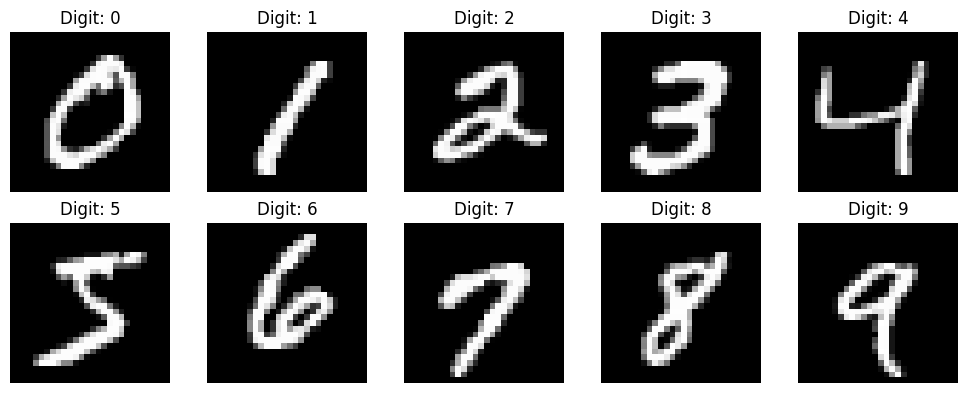

X_train: (48000, 784)
X_test: (12000, 784)
y_train: (48000,)
y_test: (12000,)


In [23]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets,
    and plots one image per class.
    """
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values   # First column is the label
    X = df.iloc[:, 1:].values  # Remaining columns are pixel values

    # Normalize pixel values
    X = X / 255.0

    # Split data into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Plot sample images
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test


# Using mnist_dataset.csv (full 60,000 samples)
X_train, X_test, y_train, y_test = load_and_prepare_mnist("/content/drive/MyDrive/mnist_dataset.csv")

print("X_train:", X_train.shape)  # (48000, 784)
print("X_test:", X_test.shape)    # (12000, 784)
print("y_train:", y_train.shape)  # (48000,)
print("y_test:", y_test.shape)    # (12000,)

In [24]:
assert len(X_train) == len(y_train), \
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

Move forward: Dimension of Feature Matrix X and label vector y matched.


In [26]:
# One-hot encode labels if not already done
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]  # Number of features
c = y_train.shape[1]  # Number of classes

# Initialize weights and biases
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha = 0.1
n_iter = 1000

# Train the model
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

Iteration 0: Cost = 2.184177
Iteration 100: Cost = 0.607340
Iteration 200: Cost = 0.489590
Iteration 300: Cost = 0.440948
Iteration 400: Cost = 0.412847
Iteration 500: Cost = 0.393966
Iteration 600: Cost = 0.380135
Iteration 700: Cost = 0.369421
Iteration 800: Cost = 0.360792
Iteration 900: Cost = 0.353639
Iteration 999: Cost = 0.347633


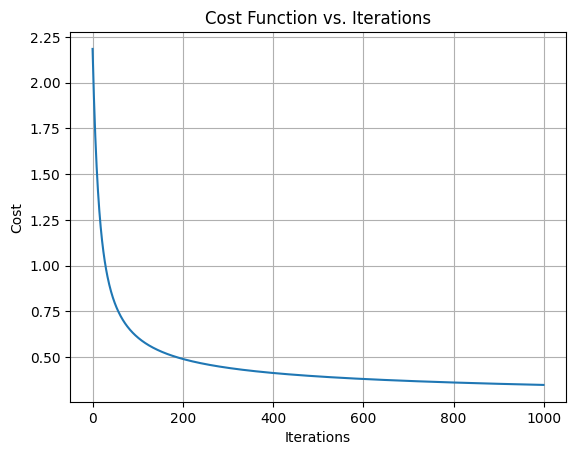

In [27]:
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [28]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix,
    precision, recall, and F1-score.
    """
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1


# Predict on test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Confusion Matrix:
[[1127    0    5    2    3   11    9    2   13    3]
 [   0 1274    7   11    1    5    1    4   18    1]
 [   2   16 1027   16   19    3   27   24   33    7]
 [   8    5   34 1048    1   53    9    8   32   21]
 [   1    5    7    1 1091    0   10    4    4   53]
 [  22   14   12   44   12  924   14    6   42   14]
 [   7    2   10    1   11   16 1118    2   10    0]
 [   7   26   24    5   15    3    0 1182    7   30]
 [   8   28   14   33    9   33   12    6 1002   15]
 [   8    6   10   18   44    9    0   39   10 1050]]
Precision: 0.90
Recall: 0.90
F1-Score: 0.90


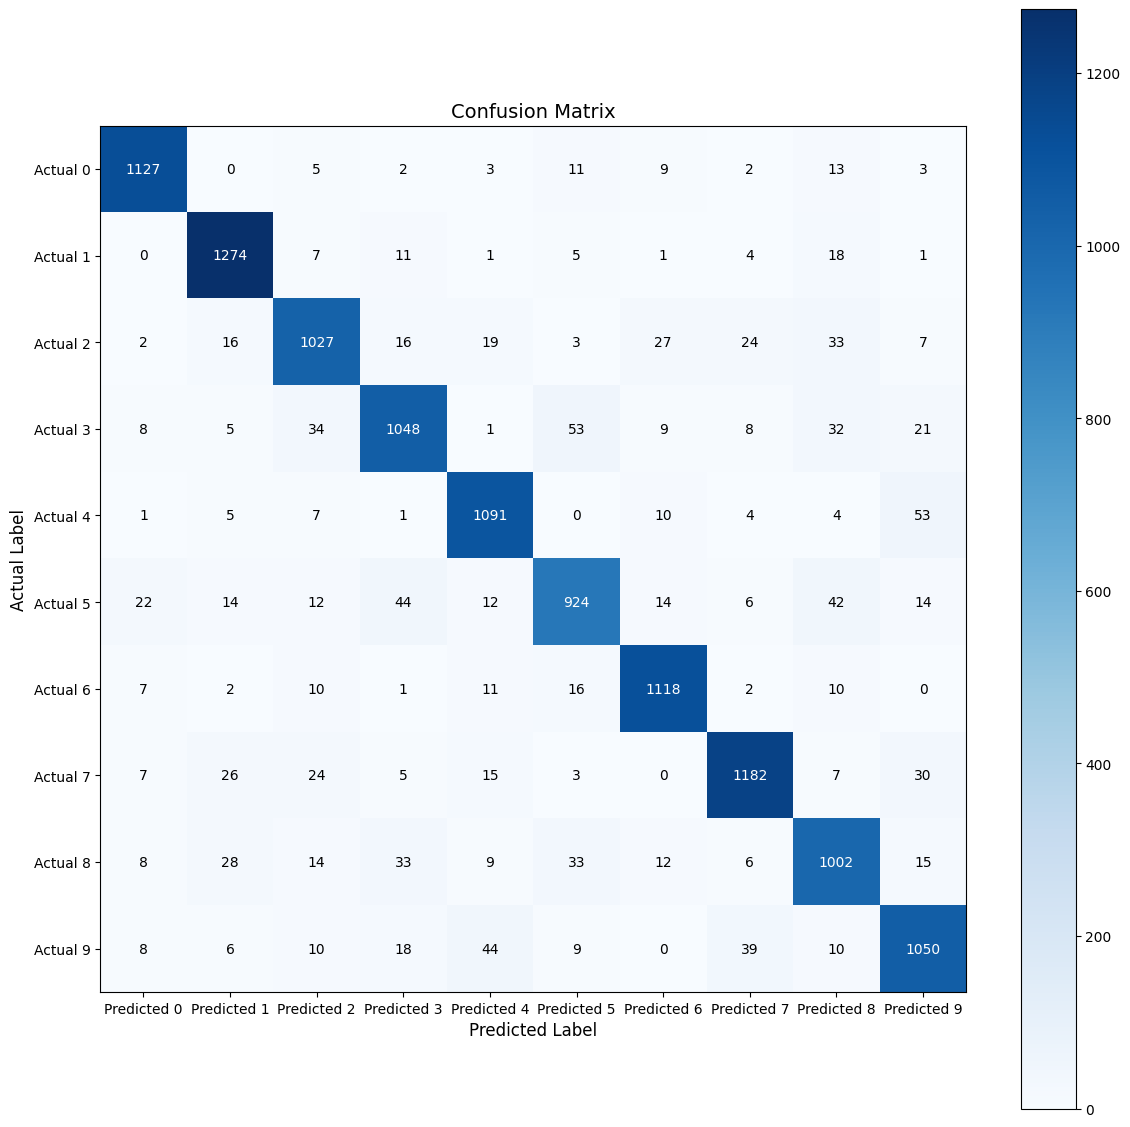

In [29]:
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

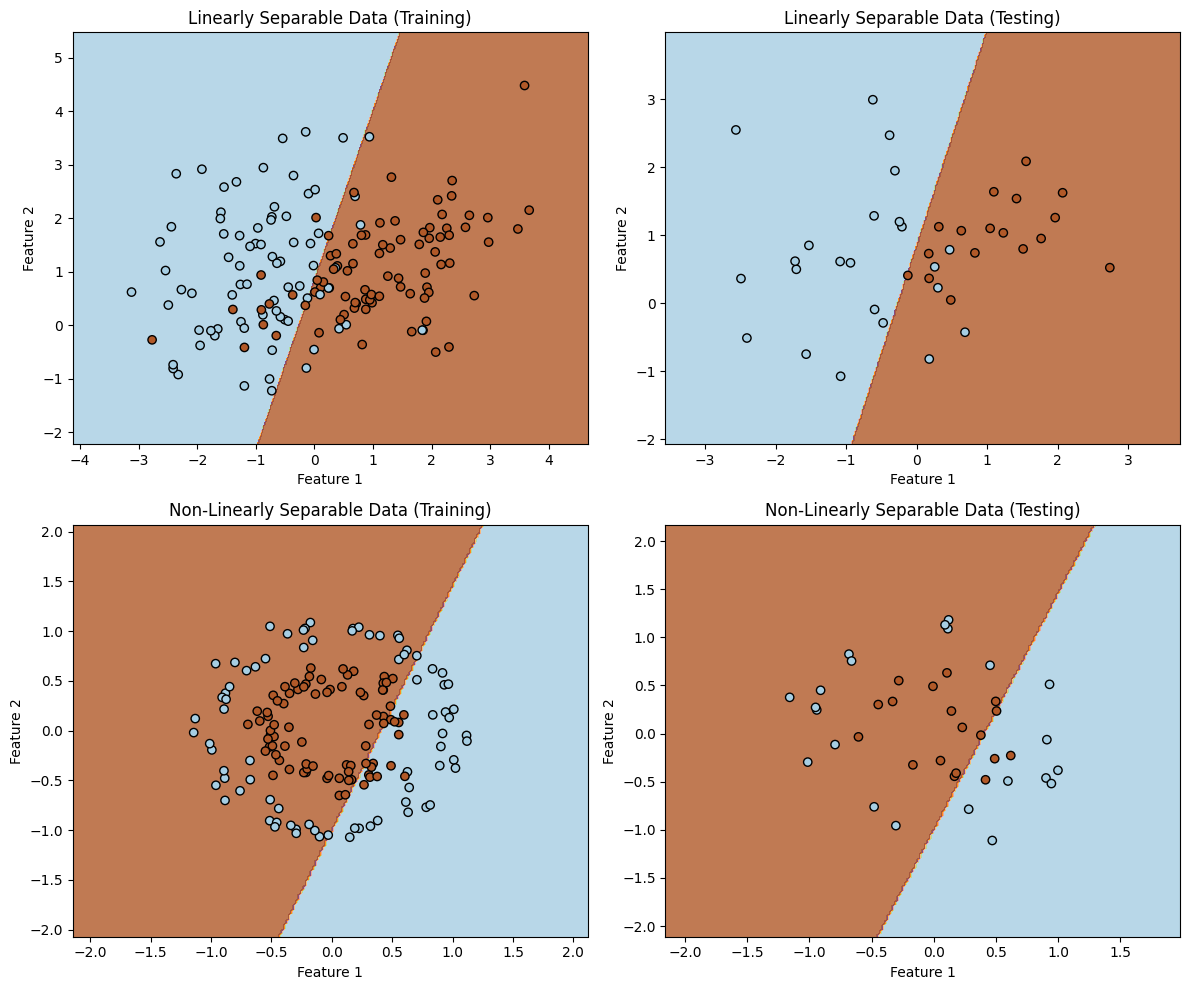

In [30]:
np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)


def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(axes[0, 0], logistic_model_linear_separable,
                       X_train_linear, y_train_linear,
                       'Linearly Separable Data (Training)')

plot_decision_boundary(axes[0, 1], logistic_model_linear_separable,
                       X_test_linear, y_test_linear,
                       'Linearly Separable Data (Testing)')

plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable,
                       X_train_non_linear, y_train_non_linear,
                       'Non-Linearly Separable Data (Training)')

plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable,
                       X_test_non_linear, y_test_non_linear,
                       'Non-Linearly Separable Data (Testing)')

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()